# CNN Generalization: Per-User Inference on Held-Out Users

**Purpose**: Load trained CNN track checkpoints and run inference on individual
held-out users to measure per-user MAE and report mean ± std

This answers: *"Does the model generalize to unseen users?"*

Separate from `CNN_diagnostics.ipynb` which answers: *"Did training go well?"*

### Models
- CNN-only (Conv1d) — original, convolves along time only
- CNN-only (Conv2d) — fixed version, convolves across electrodes and time
- CNN+LSTM v1 (Conv1d, h=128, L=1)
- CNN+LSTM v2 (Conv1d, h=256, L=2)
- CNN+LSTM v2 (Conv2d, h=256, L=2) — spatial convolution across neighboring electrodes

### Users (from 12-user metadata)
- **Test-only users** (never seen during training): `059f336bce`, `7e08fa55fd`, `fd7b487e8d`
- **Mixed users** (evaluated on held-out test portion only): 7 users with train+test splits

No retraining — inference only from saved checkpoints

In [2]:
# Mount Google Drive and set paths

from google.colab import drive
drive.mount('/content/drive')

import sys
from pathlib import Path

REPO_DIR = Path('/content/drive/Shareddrives/EMG POSE deep learning/CNN_LSTM')
sys.path.insert(0, str(REPO_DIR))

# HDF5 files live in data/data_subset on the shared drive
# (same path used by CNN_LSTM.ipynb for training)
DATA_DIR = Path('/content/drive/Shareddrives/EMG POSE deep learning/data/data_subset')
OUTPUT_DIR = REPO_DIR / 'outputs'
META_12 = REPO_DIR / 'meta_subset_12users.csv'

print(f'Repo:     {REPO_DIR}')
print(f'Data:     {DATA_DIR}')
print(f'Data exists: {DATA_DIR.exists()}')
print(f'Outputs:  {OUTPUT_DIR}')
print(f'Metadata: {META_12}')

Mounted at /content/drive
Repo:     /content/drive/Shareddrives/EMG POSE deep learning/CNN_LSTM
Data:     /content/drive/Shareddrives/EMG POSE deep learning/data/data_subset
Data exists: True
Outputs:  /content/drive/Shareddrives/EMG POSE deep learning/CNN_LSTM/outputs
Metadata: /content/drive/Shareddrives/EMG POSE deep learning/CNN_LSTM/meta_subset_12users.csv


In [3]:
# Imports

import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn.functional as F

from model import CNNPoseLSTM, CNNPoseLSTM2d, CNNOnly
from load_data import (
    build_datasets, VAL_WINDOW_LENGTH, BATCH_SIZE,
)
from data.session import load_user_scalers, DEFAULT_SCALER_PATH

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {device}')

Device: cuda


In [4]:
# Define models and checkpoints
# Same hyperparams used during training

MODELS = {
    'cnn_only': {
        'cls': CNNOnly,
        'kwargs': dict(filters=48, kernel_size=5, num_conv_layers=3),
        'label': 'CNN-only (Conv1d)',
        'color': 'tab:orange',
    },
    'cnn_only_conv2d': {
        'cls': CNNOnly,
        'kwargs': dict(filters=48, kernel_size=5, num_conv_layers=3, channel_kernel=3),
        'label': 'CNN-only (Conv2d)',
        'color': 'tab:red',
    },
    'cnn_lstm': {
        'cls': CNNPoseLSTM,
        'kwargs': dict(hidden_size=128, num_layers=1, filters=48, kernel_size=5),
        'label': 'CNN+LSTM v1',
        'color': 'tab:blue',
    },
    'cnn_lstm_v2': {
        'cls': CNNPoseLSTM,
        'kwargs': dict(hidden_size=256, num_layers=2, filters=48, kernel_size=5),
        'label': 'CNN+LSTM v2 (Conv1d)',
        'color': 'tab:green',
    },
    'cnn_lstm_v2_conv2d': {
        'cls': CNNPoseLSTM2d,
        'kwargs': dict(hidden_size=256, num_layers=2, dropout=0.1,
                       filters=48, kernel_size=5, num_conv_layers=3, channel_kernel=3),
        'label': 'CNN+LSTM v2 (Conv2d)',
        'color': 'tab:pink',
    },
}

# Load checkpoints
# Old Conv1d checkpoint won't load into the updated Conv2d CNNOnly class
# That's fine -- its cached results are already in generalization_results.json
loaded_models = {}
for name, spec in MODELS.items():
    ckpt_path = OUTPUT_DIR / name / 'best_model.pt'
    if not ckpt_path.exists():
        print(f'  SKIP {name}: checkpoint not found at {ckpt_path}')
        continue
    try:
        model = spec['cls'](**spec['kwargs']).to(device)
        ckpt = torch.load(ckpt_path, map_location=device, weights_only=True)
        model.load_state_dict(ckpt['model_state_dict'])
        model.eval()
        n_params = sum(p.numel() for p in model.parameters())
        print(f'  Loaded {spec["label"]} from epoch {ckpt["epoch"]} ({n_params:,} params)')
        loaded_models[name] = model
    except RuntimeError as e:
        print(f'  SKIP {name}: architecture mismatch (cached results will be used)')

print(f'\n{len(loaded_models)} models loaded for inference')

  SKIP cnn_only: architecture mismatch (cached results will be used)
  Loaded CNN-only (Conv2d) from epoch 34 (71,252 params)
  Loaded CNN+LSTM v1 from epoch 48 (97,700 params)
  Loaded CNN+LSTM v2 (Conv1d) from epoch 36 (848,804 params)
  Loaded CNN+LSTM v2 (Conv2d) from epoch 50 (915,092 params)

4 models loaded for inference


In [5]:
# Identify test-only users from metadata
# Original test user: 7e08fa55fd (from the 10-user cohort)
# Expansion users: 059f336bce, fd7b487e8d (test-only, 152 samples each)

meta = pd.read_csv(META_12)

# Find users that appear ONLY in the test split
# These are the ones we can use for held-out generalization
test_only_users = []
for user in sorted(meta['user'].unique()):
    splits = meta[meta['user'] == user]['split'].unique()
    if list(splits) == ['test']:
        test_only_users.append(user)

# Also grab the original test user who has both train and test splits
# Their test samples are still held-out (never trained on)
mixed_test_users = []
for user in sorted(meta['user'].unique()):
    user_splits = set(meta[meta['user'] == user]['split'].unique())
    if 'test' in user_splits and 'train' in user_splits:
        mixed_test_users.append(user)

print('Test-only users (never seen during training):')
for u in test_only_users:
    n = len(meta[(meta['user'] == u) & (meta['split'] == 'test')])
    print(f'  {u}: {n} test samples')

print(f'\nUsers with train+test splits (test portion held out):')
for u in mixed_test_users:
    n = len(meta[(meta['user'] == u) & (meta['split'] == 'test')])
    print(f'  {u}: {n} test samples')

Test-only users (never seen during training):
  059f336bce: 152 test samples
  7e08fa55fd: 154 test samples
  fd7b487e8d: 152 test samples

Users with train+test splits (test portion held out):
  0625995630: 25 test samples
  1896997952: 27 test samples
  2668760727: 25 test samples
  2942949786: 24 test samples
  3589743749: 24 test samples
  3976352430: 22 test samples
  8e69533c16: 22 test samples


In [6]:
# Build per-user dataloaders for all test users
# We evaluate each user separately to get per-user MAE

from torch.utils.data import DataLoader

# Load z-score scalers (same ones used during training)
user_scalers = None
if DEFAULT_SCALER_PATH.exists():
    user_scalers = load_user_scalers()
    print(f'Loaded scalers for {len(user_scalers)} users')

# Collect all users with test data
all_test_users = test_only_users + mixed_test_users
print(f'\nBuilding per-user test loaders for {len(all_test_users)} users...')

user_loaders = {}
for user_id in all_test_users:
    # Get HDF5 filenames for this user's test split
    user_test = meta[(meta['user'] == user_id) & (meta['split'] == 'test')]
    hdf5_paths = [DATA_DIR / f'{fn}.hdf5' for fn in user_test['filename']]

    # Filter to files that actually exist on disk
    existing = [p for p in hdf5_paths if p.exists()]
    if len(existing) == 0:
        print(f'  {user_id[:10]}: no HDF5 files found, skipping')
        continue

    ds = build_datasets(
        existing,
        window_length=VAL_WINDOW_LENGTH,
        skip_ik_failures=True,
        user_scalers=user_scalers,
    )
    loader = DataLoader(ds, batch_size=BATCH_SIZE, shuffle=False)
    user_loaders[user_id] = loader
    print(f'  {user_id[:10]}: {len(existing)} files, {len(ds)} windows')

print(f'\nReady: {len(user_loaders)} users with data')


Building per-user test loaders for 10 users...
  059f336bce: 152 files, 982 windows
  7e08fa55fd: 154 files, 1336 windows
  fd7b487e8d: 152 files, 850 windows
  0625995630: 25 files, 112 windows
  1896997952: 27 files, 213 windows
  2668760727: 25 files, 162 windows
  2942949786: 24 files, 219 windows
  3589743749: 24 files, 112 windows
  3976352430: 22 files, 146 windows
  8e69533c16: 22 files, 152 windows

Ready: 10 users with data


## 1. Per-user MAE (all models x all test users)

Run inference with each checkpoint on each user's test data separately

In [7]:
# Per-user inference
# For each (model, user) pair, compute MAE in radians
# Results are saved incrementally to disk so we dont lose progress on disconnect

GEN_DIR = OUTPUT_DIR / 'generalization'
GEN_DIR.mkdir(parents=True, exist_ok=True)
RESULTS_PATH = GEN_DIR / 'generalization_results.json'

@torch.no_grad()
def per_user_mae(model, loader, device):
    """Compute masked MAE for one user's test data"""
    model.eval()
    total_abs_error = 0.0
    total_valid = 0

    for batch in loader:
        emg = batch['emg'].to(device)
        targets = batch['joint_angles'].to(device)
        mask = batch['no_ik_failure'].to(device)

        preds = model(emg)
        mask_exp = mask.unsqueeze(1).expand_as(preds)

        if mask_exp.any():
            abs_err = torch.abs(preds[mask_exp] - targets[mask_exp])
            total_abs_error += abs_err.sum().item()
            total_valid += mask_exp.sum().item()

    if total_valid == 0:
        return float('nan')
    return total_abs_error / total_valid


# Load any previously saved results (in case we're resuming)
if RESULTS_PATH.exists():
    with open(RESULTS_PATH) as f:
        results = json.load(f)
    print(f'Loaded {sum(len(v) for v in results.values())} cached results from {RESULTS_PATH.name}')
else:
    results = {}

# Run all combinations, skipping already-computed pairs
for model_name, model in loaded_models.items():
    label = MODELS[model_name]['label']
    if model_name not in results:
        results[model_name] = {}

    for user_id, loader in user_loaders.items():
        # Skip if we already have this result
        if user_id in results[model_name]:
            deg = np.rad2deg(results[model_name][user_id])
            print(f'  {label:20s}  user {user_id[:10]}  MAE = {results[model_name][user_id]:.4f} rad  ({deg:.2f}°)  [cached]')
            continue

        mae = per_user_mae(model, loader, device)
        results[model_name][user_id] = mae
        deg = np.rad2deg(mae)
        print(f'  {label:20s}  user {user_id[:10]}  MAE = {mae:.4f} rad  ({deg:.2f}°)')

        # Save after each (model, user) pair completes
        with open(RESULTS_PATH, 'w') as f:
            json.dump(results, f, indent=2)

    print()

print(f'All results saved to {RESULTS_PATH}')

Loaded 50 cached results from generalization_results.json
  CNN-only (Conv2d)     user 059f336bce  MAE = 0.3914 rad  (22.42°)  [cached]
  CNN-only (Conv2d)     user 7e08fa55fd  MAE = 0.6020 rad  (34.49°)  [cached]
  CNN-only (Conv2d)     user fd7b487e8d  MAE = 0.4321 rad  (24.76°)  [cached]
  CNN-only (Conv2d)     user 0625995630  MAE = 0.6465 rad  (37.04°)  [cached]
  CNN-only (Conv2d)     user 1896997952  MAE = 0.5808 rad  (33.28°)  [cached]
  CNN-only (Conv2d)     user 2668760727  MAE = 0.7463 rad  (42.76°)  [cached]
  CNN-only (Conv2d)     user 2942949786  MAE = 1.0321 rad  (59.13°)  [cached]
  CNN-only (Conv2d)     user 3589743749  MAE = 0.6619 rad  (37.92°)  [cached]
  CNN-only (Conv2d)     user 3976352430  MAE = 0.7552 rad  (43.27°)  [cached]
  CNN-only (Conv2d)     user 8e69533c16  MAE = 0.9250 rad  (53.00°)  [cached]

  CNN+LSTM v1           user 059f336bce  MAE = 0.3116 rad  (17.85°)  [cached]
  CNN+LSTM v1           user 7e08fa55fd  MAE = 0.3271 rad  (18.74°)  [cached]
  CNN

## 2. Summary: Mean ± Std across test users

Our evaluation is a mix of Stage generalization (7 train+test users evaluated on 6 novel stages) and User,Stage generalization (3 test-only users evaluated on all stages)

Correct paper comparisons: Stage 15.2° ± 1.6°, User,Stage 15.8° ± 1.4° (not the pure User split at 12.2°)

In [8]:
# Build summary table from per-user results
# Each row = one model, columns = per-user MAE + mean + std
# Uses results dict (includes cached Conv1d results even though the model can't be loaded)

rows = []
for model_name in MODELS:
    if model_name not in results:
        continue
    label = MODELS[model_name]['label']
    user_maes = results[model_name]

    # Convert to degrees for readability
    maes_deg = {uid[:10]: np.rad2deg(v) for uid, v in user_maes.items()}
    mean_deg = np.mean(list(maes_deg.values()))
    std_deg = np.std(list(maes_deg.values()), ddof=1) if len(maes_deg) > 1 else 0.0

    row = {'Model': label, **maes_deg, 'Mean (°)': mean_deg, 'Std (°)': std_deg}
    rows.append(row)

# Paper benchmarks — our eval is a mix of Stage and User,Stage
rows.append({'Model': 'emg2pose Stage (paper)', 'Mean (°)': 15.2, 'Std (°)': 1.6})
rows.append({'Model': 'emg2pose User,Stage (paper)', 'Mean (°)': 15.8, 'Std (°)': 1.4})

df_summary = pd.DataFrame(rows).set_index('Model')

# Format nicely
print('Per-user MAE (degrees) — test users only, no retraining\n')
print(df_summary.round(2).to_string())

print('\n\nHeadline comparison:')
for model_name in MODELS:
    if model_name not in results:
        continue
    label = MODELS[model_name]['label']
    maes = list(results[model_name].values())
    mean_deg = np.rad2deg(np.mean(maes))
    std_deg = np.rad2deg(np.std(maes, ddof=1)) if len(maes) > 1 else 0.0
    print(f'  {label}: {mean_deg:.1f}° ± {std_deg:.1f}°')
print(f'  emg2pose Stage (paper): 15.2° ± 1.6°  (158 train users)')
print(f'  emg2pose User,Stage (paper): 15.8° ± 1.4°  (158 train users)')

Per-user MAE (degrees) — test users only, no retraining

                             059f336bce  7e08fa55fd  fd7b487e8d  0625995630  1896997952  2668760727  2942949786  3589743749  3976352430  8e69533c16  Mean (°)  Std (°)
Model                                                                                                                                                                 
CNN-only (Conv1d)                 22.97       36.62       25.71       41.47       35.37       44.62       69.52       41.26       46.50       58.90     42.29    14.03
CNN-only (Conv2d)                 22.42       34.49       24.76       37.04       33.28       42.76       59.13       37.92       43.27       53.00     38.81    11.40
CNN+LSTM v1                       17.85       18.74       17.67       21.46       21.05       19.89       23.21       21.78       21.76       21.31     20.47     1.85
CNN+LSTM v2 (Conv1d)              17.37       16.81       16.42       20.11       20.46       19.30       20

## 3. Per-user MAE bar plot

Visual comparison across models and users — colors distinguish user type:
- **Solid bars**: test-only users (never seen during training)
- **Hatched bars**: train+test users (evaluated on test portion only)

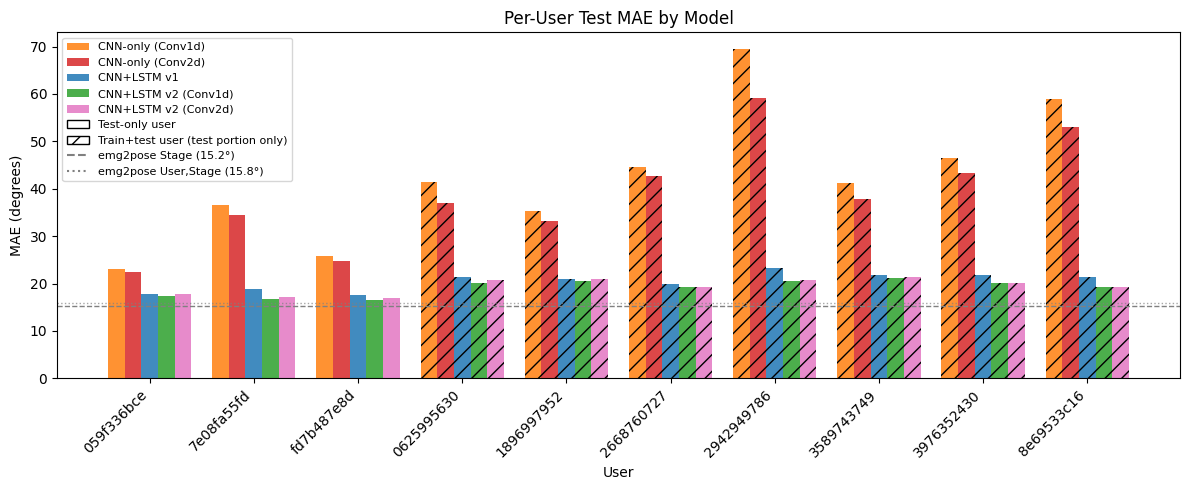

Saved to /content/drive/Shareddrives/EMG POSE deep learning/CNN_LSTM/outputs/generalization/per_user_mae_bars.png


In [9]:
# bar chart comparing per-user MAE across all models (including cached Conv1d)
# hatched bars = users with both train and test splits (evaluated on test only)
# solid bars = test-only users (never seen during training)

from matplotlib.patches import Patch

# Use all models that have results (cached or fresh)
plot_models = [m for m in MODELS if m in results]

user_ids = list(user_loaders.keys())
n_users = len(user_ids)
n_models = len(plot_models)

x = np.arange(n_users)
width = 0.8 / n_models

fig, ax = plt.subplots(figsize=(12, 5))

for i, model_name in enumerate(plot_models):
    spec = MODELS[model_name]
    maes_deg = [np.rad2deg(results[model_name][uid]) for uid in user_ids]

    bars = ax.bar(
        x + i * width, maes_deg, width,
        label=spec['label'], color=spec['color'], alpha=0.85,
    )

    # mark the train+test users with hatching so we can tell them apart
    for j, uid in enumerate(user_ids):
        if uid in mixed_test_users:
            bars[j].set_hatch('//')

ax.set_xlabel('User')
ax.set_ylabel('MAE (degrees)')
ax.set_title('Per-User Test MAE by Model')
ax.set_xticks(x + width * (n_models - 1) / 2)
ax.set_xticklabels(user_ids, rotation=45, ha='right')

# Benchmark lines — our eval is a mix of Stage and User,Stage
ax.axhline(y=15.2, color='gray', linestyle='--', linewidth=1)
ax.axhline(y=15.8, color='gray', linestyle=':', linewidth=1, alpha=0.7)

# build the legend so it explains the hatching too
handles, labels = ax.get_legend_handles_labels()
handles.append(Patch(facecolor='white', edgecolor='black', label='Test-only user'))
handles.append(Patch(facecolor='white', edgecolor='black', hatch='//', label='Train+test user (test portion only)'))
handles.append(plt.Line2D([0], [0], color='gray', linestyle='--', label='emg2pose Stage (15.2°)'))
handles.append(plt.Line2D([0], [0], color='gray', linestyle=':', label='emg2pose User,Stage (15.8°)'))
ax.legend(handles=handles, fontsize=8)

ax.set_ylim(bottom=0)
plt.tight_layout()
plt.savefig(GEN_DIR / 'per_user_mae_bars.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved to {GEN_DIR / "per_user_mae_bars.png"}')

## 4. Key takeaways

**Conv2d vs Conv1d**: Conv2d improves CNN-only generalization by ~8% relative (38.8° vs 42.3°) and reduces worst-user error from 70° to 59°. Spatial convolution across electrodes captures some cross-channel structure, but not enough to close the gap with LSTM-based models

**Temporal context is essential**: CNN-only (both variants) collapses on unseen users (38-42°) while CNN+LSTM v2 holds at 19.2°. The LSTM decoder is what enables generalization, not the CNN feature extractor

**Why the gap vs the paper benchmark**: We trained on 8 users; the paper trained on 158. The emg2pose paper's Fig. 6 shows log-linear improvement with more training users. CNN+LSTM v2 at 19.2° vs the paper's Stage benchmark at 15.2° is a ~4° gap with 20x fewer training users

**Per-user spread**: CNN-only's per-user range is 22-59° (Conv2d) vs CNN+LSTM v2's 16-21°. Aggregate metrics hide this — the worst CNN-only user is 3x worse than the best

**Caveats**:
- Our eval is a mix of Stage and User,Stage generalization (see Section 2 header)
- The 12.2° paper benchmark is the pure User split — not directly comparable to our setup
- Correct comparisons: Stage 15.2° ± 1.6°, User,Stage 15.8° ± 1.4°

In [10]:
# Release GPU and disconnect runtime to save compute units
import gc
if torch.cuda.is_available():
    torch.cuda.empty_cache()
gc.collect()

from google.colab import runtime
print('All done — disconnecting runtime')
runtime.unassign()

All done — disconnecting runtime
